In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [31]:
# Load the dataset
df = pd.read_csv('KaggleV2-May-2016.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\n" + "="*50 + "\n")

print("First 5 rows of the dataset:")
df.head()

Dataset Shape: (110527, 14)


First 5 rows of the dataset:


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [32]:
# Check data types and missing values
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [33]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [34]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [35]:
# Check unique values in categorical columns
print("Unique values in key columns:")
print(f"Gender: {df['Gender'].unique()}")
print(f"Scholarship: {df['Scholarship'].unique()}")
print(f"Hipertension: {df['Hipertension'].unique()}")
print(f"Diabetes: {df['Diabetes'].unique()}")
print(f"Alcoholism: {df['Alcoholism'].unique()}")
print(f"Handcap: {df['Handcap'].unique()}")
print(f"SMS_received: {df['SMS_received'].unique()}")
print(f"No-show: {df['No-show'].unique()}")

Unique values in key columns:
Gender: ['F' 'M']
Scholarship: [0 1]
Hipertension: [1 0]
Diabetes: [0 1]
Alcoholism: [0 1]
Handcap: [0 1 2 3 4]
SMS_received: [0 1]
No-show: ['No' 'Yes']


In [36]:
# Rename columns for consistency and fix spelling errors
df = df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'No-show': 'NoShow'
})

# Check column names after renaming
print("Updated column names:")
df.columns.tolist()

Updated column names:


['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hypertension',
 'Diabetes',
 'Alcoholism',
 'Handicap',
 'SMS_received',
 'NoShow']

In [37]:
# Check for invalid values in Age column
print(f"Age statistics:")
print(df['Age'].describe())
print(f"\nMinimum age: {df['Age'].min()}")
print(f"Maximum age: {df['Age'].max()}")

Age statistics:
count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

Minimum age: -1
Maximum age: 115


In [38]:
# Check records with invalid age (negative values)
invalid_age = df[df['Age'] < 0]
print(f"Records with negative age: {len(invalid_age)}")
invalid_age

Records with negative age: 1


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


In [39]:
# Handle negative age - replace with median age
median_age = df[df['Age'] >= 0]['Age'].median()
print(f"Median age (excluding negatives): {median_age}")

# Replace negative age with median
df.loc[df['Age'] < 0, 'Age'] = median_age

# Verify the fix
print(f"\nAfter fix - Age statistics:")
print(df['Age'].describe())
print(f"Minimum age after fix: {df['Age'].min()}")

Median age (excluding negatives): 37.0

After fix - Age statistics:
count    110527.000000
mean         37.089218
std          23.109921
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64
Minimum age after fix: 0


In [40]:
# Convert date columns to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Extract date components for analysis
df['ScheduledDate'] = df['ScheduledDay'].dt.date
df['AppointmentDate'] = df['AppointmentDay'].dt.date
df['ScheduledHour'] = df['ScheduledDay'].dt.hour
df['ScheduledWeekday'] = df['ScheduledDay'].dt.dayofweek
df['AppointmentWeekday'] = df['AppointmentDay'].dt.dayofweek

# Calculate waiting time (days between scheduling and appointment)
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Check waiting time statistics
print("Waiting time statistics (in days):")
print(df['WaitingDays'].describe())

Waiting time statistics (in days):
count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: WaitingDays, dtype: float64


In [41]:
# Check for negative waiting days (appointment before scheduling)
negative_wait = df[df['WaitingDays'] < 0]
print(f"Records with negative waiting days: {len(negative_wait)}")
negative_wait[['PatientId', 'ScheduledDay', 'AppointmentDay', 'WaitingDays']].head()

Records with negative waiting days: 38568


,PatientId,ScheduledDay,AppointmentDay,WaitingDays
0,2.987250e+13,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1
1,5.589978e+14,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1
2,4.262962e+12,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1
3,8.679512e+11,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1
4,8.841186e+12,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1


In [42]:
# Check unique values in Handicap
print("Handicap unique values:", df['Handicap'].unique())
print("Handicap value counts:")
print(df['Handicap'].value_counts().sort_index())

Handicap unique values: [0 1 2 3 4]
Handicap value counts:
Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


In [43]:
# According to this documentation, Handicap should be binary (0 or 1)
# But we see values 2, 3, 4. Let's treat any positive value as 1 (has handicap)
df['Handicap'] = df['Handicap'].apply(lambda x: 1 if x > 0 else 0)

print("After fixing - Handicap value counts:")
print(df['Handicap'].value_counts())

After fixing - Handicap value counts:
Handicap
0    108286
1      2241
Name: count, dtype: int64


In [44]:
# Select numerical columns for exploration
numerical_cols = ['Age', 'Scholarship', 'Hypertension', 'Diabetes',
                  'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays']

print("Descriptive Statistics for Numerical Features:")
df[numerical_cols].describe()

Descriptive Statistics for Numerical Features:


,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.089218,0.098266,0.197246,0.071865,0.030400,0.020276,0.321026,9.183702
std,23.109921,0.297675,0.397921,0.258265,0.171686,0.140942,0.466873,15.254996
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,14.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,178.000000


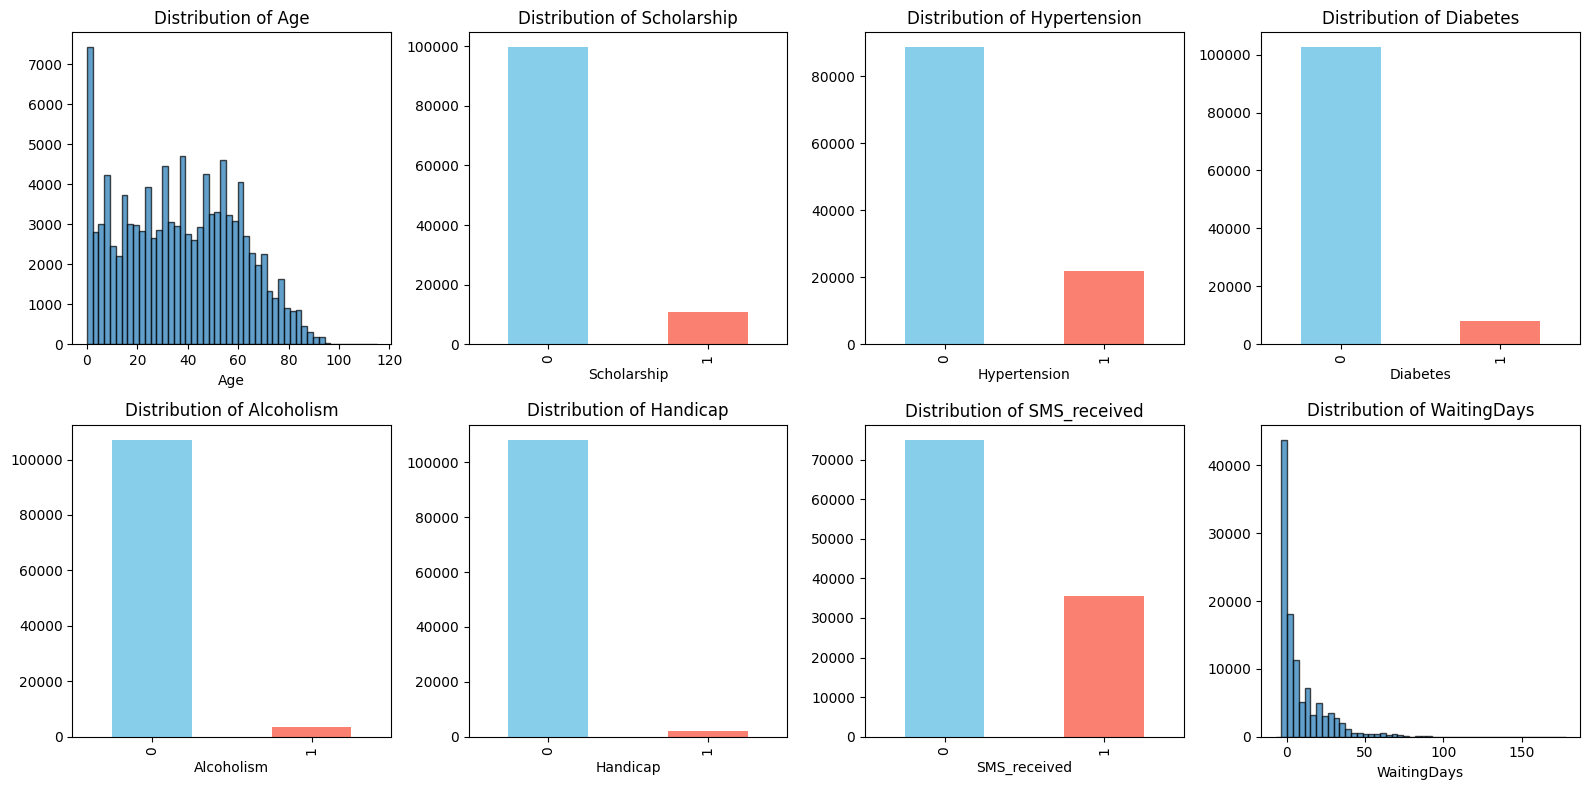

In [45]:
# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if col in ['Age', 'WaitingDays']:
        # For continuous variables
        axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    else:
        # For binary variables
        df[col].value_counts().plot(kind='bar', ax=axes[i], color=['skyblue', 'salmon'])

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

No-show distribution:
NoShow
No     88208
Yes    22319
Name: count, dtype: int64

Percentage:
NoShow
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


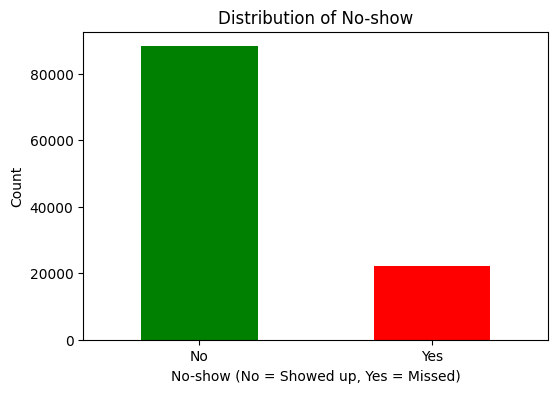

In [46]:
# Analyze target variable (NoShow)
print("No-show distribution:")
print(df['NoShow'].value_counts())
print(f"\nPercentage:")
print(df['NoShow'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(6, 4))
df['NoShow'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of No-show')
plt.xlabel('No-show (No = Showed up, Yes = Missed)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [47]:
# Create a copy for encoding
df_encoded = df.copy()

# 1. Encode Gender (binary categorical)
df_encoded['Gender'] = df_encoded['Gender'].map({'F': 0, 'M': 1})

# 2. Encode No-show (target variable)
df_encoded['NoShow'] = df_encoded['NoShow'].map({'No': 0, 'Yes': 1})

print("After encoding Gender and NoShow:")
print(f"Gender unique values: {df_encoded['Gender'].unique()}")
print(f"NoShow unique values: {df_encoded['NoShow'].unique()}")

After encoding Gender and NoShow:
Gender unique values: [0 1]
NoShow unique values: [0 1]


In [48]:
# 3. One-hot encode Neighborhood (high cardinality categorical)
# Get top 10 neighborhoods by frequency for analysis
top_neighbourhoods = df_encoded['Neighbourhood'].value_counts().head(10)
print("Top 10 neighborhoods:")
print(top_neighbourhoods)

Top 10 neighborhoods:
Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64


In [49]:
# Apply one-hot encoding to Neighborhood
neighbourhood_dummies = pd.get_dummies(df_encoded['Neighbourhood'], prefix='Nbr')

# Add encoded columns to dataframe
df_encoded = pd.concat([df_encoded, neighbourhood_dummies], axis=1)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
print(f"Number of columns increased by: {len(neighbourhood_dummies.columns)}")

Shape after one-hot encoding: (110527, 101)
Number of columns increased by: 81


In [50]:
# 4. Create age groups for better analysis
bins = [0, 18, 35, 50, 65, 120]
labels = ['0-17', '18-34', '35-49', '50-64', '65+']
df_encoded['AgeGroup'] = pd.cut(df_encoded['Age'], bins=bins, labels=labels)

print("Age group distribution:")
print(df_encoded['AgeGroup'].value_counts().sort_index())

Age group distribution:
AgeGroup
0-17     25327
18-34    24137
35-49    22101
50-64    22122
65+      13301
Name: count, dtype: int64


In [51]:
# Create additional useful features

# 1. Is weekend appointment (0-4 weekday, 5-6 weekend)
# In the data, appointments are only on weekdays, so this feature may not be useful

# 2. Appointment hour (from ScheduledDay)
df_encoded['AppointmentHour'] = df_encoded['ScheduledDay'].dt.hour

# 3. Appointment month
df_encoded['AppointmentMonth'] = df_encoded['AppointmentDay'].dt.month

# 4. Number of medical conditions
df_encoded['Conditions_Count'] = (df_encoded['Hypertension'] +
                                   df_encoded['Diabetes'] +
                                   df_encoded['Alcoholism'])

print("New features created:")
print(df_encoded[['AppointmentHour', 'AppointmentMonth', 'Conditions_Count']].head())

New features created:
   AppointmentHour  AppointmentMonth  Conditions_Count
0               18                 4                 1
1               16                 4                 0
2               16                 4                 0
3               17                 4                 0
4               16                 4                 2


In [52]:
# 5. Patient has multiple appointments flag
patient_appointment_counts = df_encoded.groupby('PatientId')['AppointmentID'].count()
df_encoded['HasMultipleAppointments'] = df_encoded['PatientId'].map(
    lambda x: 1 if patient_appointment_counts[x] > 1 else 0
)

print(f"Patients with multiple appointments: {df_encoded['HasMultipleAppointments'].sum()}")
print(f"Percentage: {df_encoded['HasMultipleAppointments'].mean() * 100:.2f}%")

Patients with multiple appointments: 72607
Percentage: 65.69%


In [53]:
# Select relevant columns for analysis
# Keep original columns + engineered features
final_columns = [
    'PatientId', 'AppointmentID', 'Gender', 'Age', 'AgeGroup',
    'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes',
    'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays',
    'AppointmentHour', 'AppointmentMonth', 'Conditions_Count',
    'HasMultipleAppointments', 'NoShow'
]

# Add top neighborhood dummies (optional - for modeling)
top_nbrs = top_neighbourhoods.index.tolist()
nbr_dummies_to_keep = [f'Nbr_{nbr}' for nbr in top_nbrs]

# Create final dataset
df_final = df_encoded[final_columns + nbr_dummies_to_keep].copy()

print("Final dataset shape:", df_final.shape)
print("\nFirst few rows of final dataset:")
df_final.head()

Final dataset shape: (110527, 28)

First few rows of final dataset:


,PatientId,AppointmentID,Gender,Age,AgeGroup,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentHour,AppointmentMonth,Conditions_Count,HasMultipleAppointments,NoShow,Nbr_JARDIM CAMBURI,Nbr_MARIA ORTIZ,Nbr_RESISTÊNCIA,Nbr_JARDIM DA PENHA,Nbr_ITARARÉ,Nbr_CENTRO,Nbr_TABUAZEIRO,Nbr_SANTA MARTHA,Nbr_JESUS DE NAZARETH,Nbr_BONFIM
0,2.987250e+13,5642903,0,62,50-64,JARDIM DA PENHA,0,1,0,0,0,0,-1,18,4,1,1,0,False,False,False,True,False,False,False,False,False,False
1,5.589978e+14,5642503,1,56,50-64,JARDIM DA PENHA,0,0,0,0,0,0,-1,16,4,0,1,0,False,False,False,True,False,False,False,False,False,False
2,4.262962e+12,5642549,0,62,50-64,MATA DA PRAIA,0,0,0,0,0,0,-1,16,4,0,1,0,False,False,False,False,False,False,False,False,False,False
3,8.679512e+11,5642828,0,8,0-17,PONTAL DE CAMBURI,0,0,0,0,0,0,-1,17,4,0,1,0,False,False,False,False,False,False,False,False,False,False
4,8.841186e+12,5642494,0,56,50-64,JARDIM DA PENHA,0,1,1,0,0,0,-1,16,4,2,0,0,False,False,False,True,False,False,False,False,False,False


In [54]:
# Save the cleaned and preprocessed dataset
df_final.to_csv('medical_appointments_cleaned.csv', index=False)
print("Cleaned dataset saved as 'medical_appointments_cleaned.csv'")

Cleaned dataset saved as 'medical_appointments_cleaned.csv'


In [55]:
print("Final Dataset Summary:")
print(f"Total records: {len(df_final)}")
print(f"Total features: {len(df_final.columns)}")
print(f"\nFeature types:")
print(df_final.dtypes.value_counts())
print(f"\nMissing values in final dataset: {df_final.isnull().sum().sum()}")

Final Dataset Summary:
Total records: 110527
Total features: 28

Feature types:
int64       13
bool        10
int32        2
float64      1
object       1
category     1
Name: count, dtype: int64

Missing values in final dataset: 3539
